In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
import json
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)


<module 'utils.linear_reservoir' from 'c:\\Users\\huan1428\\Documents\\karst\\UMNBearSpring\\src\\utils\\linear_reservoir.py'>

# Load Network

In [13]:
network_dir = '../../data/networks/single_conduit/pykasso_n58'
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
network.extract_diffuse_inlets()

In [14]:
network.plot_3D_network(node_color = 'type')

# Load and Write Recharge

In [3]:
#just a box injection for 1 day
from scipy.stats import norm

baseflow = 0.02 #m3/s
peakflow = baseflow * 10
duration = 6 * 3600 # seconds
dt = 1800 
t = np.arange(0, 24*3600, dt)
def gaussian_recharge(t, peak, center, duration):
    """
    t        : time array
    peak    : max recharge value
    center  : time of peak
    duration: FWHM (event duration)
    """

    sigma = duration / 2.355

    return peak * np.exp(-(t-center)**2 / (2*sigma**2))

gauss_R  = (gaussian_recharge(t, peakflow - baseflow, 12*3600, duration) + baseflow) * 86400 # m3/d
#TO DO: partition recharge, save recharge/BC files, run test model


In [4]:
gauss_R_dict = {'flow' : gauss_R, 'time' : t}
write_pickle( f'input_data/gaussian_recharge.pkl', gauss_R_dict)

In [170]:
gauss_R

array([ 1728.23690277,  1728.58565465,  1729.39311382,  1731.18863761,
        1735.02258951,  1742.8820568 ,  1758.34605124,  1787.54084189,
        1840.4090586 ,  1932.20257084,  2084.93953643,  2328.3460539 ,
        2699.58817528,  3240.99096993,  3995.06517989,  4996.62601094,
        6262.61075113,  7781.24635944,  9503.17621967, 11337.60833788,
       13156.11729016, 14805.2746793 , 16127.03402476, 16983.37982829,
       17280.        , 16983.37982829, 16127.03402476, 14805.2746793 ,
       13156.11729016, 11337.60833788,  9503.17621967,  7781.24635944,
        6262.61075113,  4996.62601094,  3995.06517989,  3240.99096993,
        2699.58817528,  2328.3460539 ,  2084.93953643,  1932.20257084,
        1840.4090586 ,  1787.54084189,  1758.34605124,  1742.8820568 ,
        1735.02258951,  1731.18863761,  1729.39311382,  1728.58565465])

In [5]:
A = 4629284 #springshed area 
n =.01 #effective porosity
d = 10 # m 
V_l = A * d * n#m^3
S_max = .3 #m
S_0 = 0.3
k = 1 #1 / d 
eta = 0.3
alpha_l = 0.1 #1 /d 
alpha_h = 0.5 #1 /d 

In [6]:
n_days = 100000
# steady_state_R = np.ones(n_days) * baseflow / A * 86400 # m / d 
steady_state_R = np.ones(n_days) * baseflow * 86400 # m3 / d
steady_state_t = np.arange(0, n_days)

In [7]:
ss = lr.linear_reservoir_model(steady_state_R * (1-eta), steady_state_R * eta, steady_state_t, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = 0, dt_unit = 'D')
# ss = lr.full_model(steady_state_R , np.zeros(n_days), steady_state_t/86400, A = A, eta = eta, V_l = V_l, S_max = S_max, S_0 = S_0, k = k, n_l = eta, alpha_l = alpha_l, alpha_h = alpha_h, dt_unit = 'D')

No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='Q_l [V/T]'>

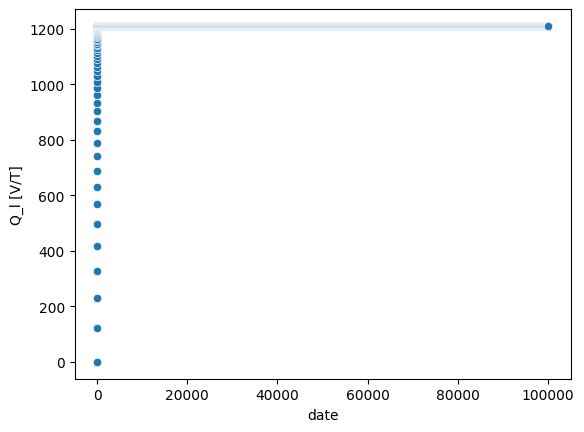

In [8]:
sns.scatterplot(ss, x = 'date', y = 'Q_l [V/T]')

In [9]:
V_l0 = ss['V_l [V]'].iloc[-1] #initial V_l 
pulse = lr.linear_reservoir_model(gauss_R * (1-eta), gauss_R * eta, t / 86400, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = V_l0, dt_unit = 'D')


No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='None'>

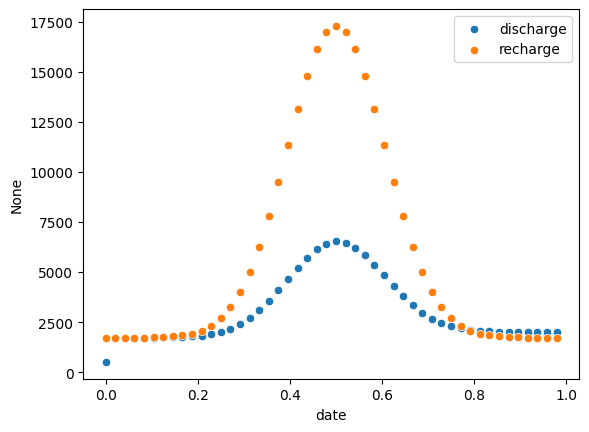

In [11]:
sns.scatterplot(pulse, x = 'date', y = pulse['R_h [V/T]'] + pulse['Q_l [V/T]'], label = 'discharge')
sns.scatterplot(x = t/86400, y = gauss_R, label = "recharge")
# sns.scatterplot(ss, x = 'date', y = 'R_h [L/T]')

In [18]:
def write_recharge(R_l, R_h, t_l, t_h, network):
    n_diffuse = len(network.diffuse_inlets)
    n_point = len(network.inlets)
    R_l_per_inlet = R_l / n_diffuse 
    R_h_per_inlet = R_h / n_point 
    R = {network.inlets : {'flow' : R_h_per_inlet, 'time' : t_h}, network.diffuse_inlets : {'flow' : R_l_per_inlet, 'time' : t_l}} 
    return R

    

In [20]:
write_recharge(pulse['Q_l [V/T]'], pulse['R_h [V/T]'], t, t, network)

{(0,): {'flow': 0      518.471071
  1      518.575696
  2      518.817934
  3      519.356591
  4      520.506777
  5      522.864617
  6      527.503815
  7      536.262253
  8      552.122718
  9      579.660771
  10     625.481861
  11     698.503816
  12     809.876453
  13     972.297291
  14    1198.519554
  15    1498.987803
  16    1878.783225
  17    2334.373908
  18    2850.952866
  19    3401.282501
  20    3946.835187
  21    4441.582404
  22    4838.110207
  23    5095.013948
  24    5184.000000
  25    5095.013948
  26    4838.110207
  27    4441.582404
  28    3946.835187
  29    3401.282501
  30    2850.952866
  31    2334.373908
  32    1878.783225
  33    1498.987803
  34    1198.519554
  35     972.297291
  36     809.876453
  37     698.503816
  38     625.481861
  39     579.660771
  40     552.122718
  41     536.262253
  42     527.503815
  43     522.864617
  44     520.506777
  45     519.356591
  46     518.817934
  47     518.575696
  Name: R_h [V/T], dtype: 

In [ ]:
R = {network.inlets : {'flow' : rech_limited_range['R_h_per_inlet'], 'time' : rech_limited_range['time (s)']}} 
pickle.dump(R, f)
print (f'results saved to input_data/inflow_boundary.pkl')

array([0.02000274, 0.02000678, 0.02001612, 0.02003691, 0.02008128,
       0.02017225, 0.02035123, 0.02068913, 0.02130103, 0.02236346,
       0.02413124, 0.02694845, 0.03124523, 0.03751147, 0.04623918,
       0.05783132, 0.07248392, 0.09006072, 0.10999047, 0.13122232,
       0.15226988, 0.17135735, 0.18665549, 0.1965669 , 0.2       ,
       0.1965669 , 0.18665549, 0.17135735, 0.15226988, 0.13122232,
       0.10999047, 0.09006072, 0.07248392, 0.05783132, 0.04623918,
       0.03751147, 0.03124523, 0.02694845, 0.02413124, 0.02236346,
       0.02130103, 0.02068913, 0.02035123, 0.02017225, 0.02008128,
       0.02003691, 0.02001612, 0.02000678])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, '0.0'),
  Text(1, 0, '0.5'),
  Text(2, 0, '1.0'),
  Text(3, 0, '1.5'),
  Text(4, 0, '2.0'),
  Text(5, 0, '2.5'),
  Text(6, 0, '3.0'),
  Text(7, 0, '3.5'),
  Text(8, 0, '4.0'),
  Text(9, 0, '4.5'),
  Text(10, 0, '5.0'),
  Text(11, 0, '5.5'),
  Text(12, 0, '6.0'),
  Text(13, 0, '6.5'),
  Text(14, 0, '7.0'),
  Text(15, 0, '7.5'),
  Text(16, 0, '8.0'),
  Text(17, 0, '8.5'),
  Text(18, 0, '9.0'),
  Text(19, 0, '9.5'),
  Text(20, 0, '10.0'),
  Text(21, 0, '10.5'),
  Text(22, 0, '11.0'),
  Text(23, 0, '11.5'),
  Text(24, 0, '12.0'),
  Text(25, 0, '12.5'),
  Text(26, 0, '13.0'),
  Text(27, 0, '13.5'),
  Text(28, 0, '14.0'),
  Text(29, 0, '14.5'),
  Text(30, 0, '15.0'),
  Text(31, 0, '15.5'),
  Text(32, 0, '

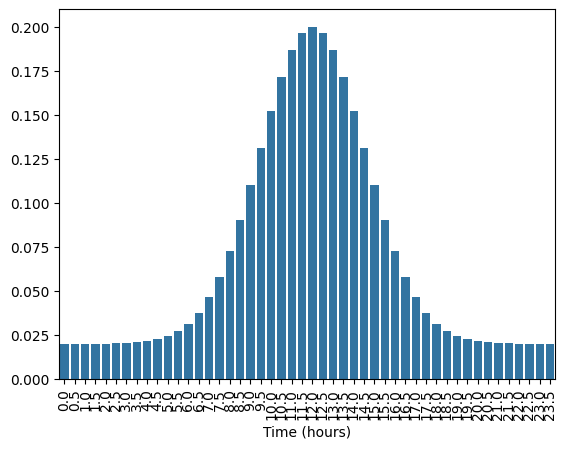

In [38]:
sns.barplot(x=t/3600, y=gauss_R)
plt.xlabel('Time (hours)')
plt.xticks(rotation=90)
